In [ ]:
!pip install -U langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 12.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.27
    Uninstalling langchain-0.3.27:
      Successfully uninstalled langchain-0.3.27


In [ ]:
!pip install --quiet --upgrade langchain-text-splitters langchain-community langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!pip install -qU "langchain[groq]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
import getpass
import os

if not os.environ.get("GROQ_API_KEY"):
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter API key for Groq: ")

Enter API key for Groq: ··········


In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("llama-3.1-8b-instant", model_provider="groq")

In [ ]:
from langchain_groq import ChatGroq




# Memory containers
MAX_MEMORY_LENGTH = 3  # how many messages to keep in short memory

def summarize_conversation(conversation):
    """Use the model itself to generate a short summary of the conversation."""
    prompt = (
        "Summarize this conversation in 3 concise sentences, keeping only important facts about the user:\n\n"
        + "\n".join(conversation)
    )
    return llm.invoke(prompt).content

def talk(state,system_prompt):

    memory = state["messages"]
    summary = state["summary"]

    # Initialize the model
    llm = ChatGroq(model="llama-3.1-8b-instant")
    # Keep only the last few messages (short-term)
    limited_memory = memory[-MAX_MEMORY_LENGTH:]
    context = "\n".join(limited_memory)

    user_input=state["reponce"]
    # Build the full prompt with system + summary + short-term
    prompt = f"{system_prompt}\n\nSummary of previous talks: {summary}\n\n{context}\nUser: {user_input}\nAI:"

    # Get the model's reply
    state["answer"] = llm.invoke(prompt)


    # Save the new exchange
    state["messages"].append(f"User: {user_input}")
    state["messages"].append(f"AI: {state["answer"].content}")

    # If conversation grows too long, summarize it and reset
    if len(state["messages"]) > MAX_MEMORY_LENGTH * 2:
        summary_update = summarize_conversation(state["messages"][:-MAX_MEMORY_LENGTH])
        state["summary"] = summary + " " + summary_update
        state["messages"] = state["messages"][-MAX_MEMORY_LENGTH:]  # keep only the last messages

    return state


In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_core.messages import HumanMessage, AIMessage
import json
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [ ]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict

class AgentState(TypedDict):
    name:str
    intro:str
    impro_intro:str
    question1:str
    score_question1:int
    impro_question1:str
    question2:str
    score_question2:int
    impro_question2:str
    question3:str
    score_question3:int
    impro_question3:str
    reponce: str
    summary:str
    messages: List[str]
    answer: str

In [ ]:
def name(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("You are an AI interviewer."
                      "did the user proveide his name ?"
                      "answer only only with  yes or no !!!"
                      "if the use did ask anything not related to his full name JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is the full name of the user"
                      "return only the full name"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    print(response.content)
    state["name"] = response.content
    base_instruction = ( """
                        You are an AI interviewer. The user has already provided their full name.
                        Now, ask politely about their background.

                        Say something like:
                        "Nice to meet you. Could you tell me a bit about your background — for example, your education, what you’re currently doing, or your area of expertise?"
                        """)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    print(response.content)
  else:
    base_instruction = ("You are an AI interviewer. Your first task is to ask the user for their full name."
                        "Say something polite and natural like:"
                        "Hello! I’m your AI interviewer. Could you please tell me your full name?")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    print(response.content)

  return state

In [ ]:
name({"name":"","intro":"","question1":"","score_question1":0,"question2":"","score_question2":0,"question3":"","reponce":"","summary":"","messages":[],"answer":""})

node name :
No.
Hello! I'm your AI interviewer. Could you please tell me your full name?


{'name': '',
 'intro': '',
 'question1': '',
 'score_question1': 0,
 'question2': '',
 'score_question2': 0,
 'question3': '',
 'reponce': '',
 'summary': '',
 'messages': ['User: ',
  "AI: Hello! I'm your AI interviewer. Could you please tell me your full name?"],
 'answer': AIMessage(content="Hello! I'm your AI interviewer. Could you please tell me your full name?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 89, 'total_tokens': 107, 'completion_time': 0.016088041, 'prompt_time': 0.005722596, 'queue_time': 0.054569104, 'total_time': 0.021810637}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--00efc39d-4e6a-45c9-9b12-2ffa4cf4ba9c-0', usage_metadata={'input_tokens': 89, 'output_tokens': 18, 'total_tokens': 107})}

In [ ]:
def into(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("You are an AI interviewer."
                      "did the user proveide their background ?"
                      "answer only only with  yes or no !!!"
                      "if the use did ask anything not related to their background JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  #print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("what is their background of the user"
                      "return only their background"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["intro"] = response.content
    base_instruction = ( """
You are an AI interviewer.
Now, begin the interview by asking the first technical question:
"What is the difference between a compiled and an interpreted language?"
""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)
  else:
    base_instruction = ("You are an AI interviewer. Now your task is to ask the user for their background."
                        "Say something polite and natural"
                        "Say something like:"
                        "Nice to meet you, {user_name}. Could you tell me a bit about your background — for example, your education, what you’re currently doing, or your area of expertise?")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)

  return state

In [ ]:
#into({"name":"","intro":"","question1":"","score_question1":0,"question2":"","score_question2":0,"question3":"","reponce":"i'm AI engenering studenet in seconde year, i like creating ai it feel like magic","summary":"","messages":[],"answer":""})

In [ ]:
def question1(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("You are an AI interviewer."
                      "you did ask the user his first technical question "
                      f"question :{state["question1"]}"
                      "did the user proveide a answer to the question even it's wrong answer"
                      "answer only with  yes or no !!!"
                      "if the user asnwer wrong say yes"
                      "if the user did ask anything not related to the question JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("You are an AI interviewer."
                      "you did ask the user his first technical question "
                      f"question :{state["question1"]}"
                      "did the user proveide a answer to the question"
                      "give a score from 0 to 10 of the user answer 0 if the user did answer wrong and 10 if the user really did answer the question with detail"
                      "return only the score nothing else"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    state["score_question1"] = response.content

    base_instruction = ("You are an AI interviewer. "
    "You asked the user their first technical question: "
    f"Question:{state["question1"]}"
    "Did the user provide an answer to this question? "
    "Evaluate the user's answer, explain how they can improve, and identify their negative traits. "
    "make it simple and short, really short and to the point"
    f"Summary of previous talks: {summary}\n\n"
    f"{context}\n"
    f"User: {reponce}\n"
    "AI:")
    human_message = HumanMessage(content=state["reponce"])
    system_instruction = SystemMessage(content=base_instruction)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    state["impro_question1"] = response.content
    #print(response.content)

    base_instruction = (
"You are an AI interviewer."
f"Now, ask the user his seconde technical question: {state['question2']}"
)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)
  else:
    base_instruction = ("You are an AI interviewer. The user has already provided their full name."
"Now, begin the interview by asking the first technical question:"
f"question : {state['question1']}"
)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)

  return state

In [ ]:
#question1({"name":"","intro":"","question1":"","score_question1":0,"question2":"","score_question1":"","impro_question1":"","score_question2":0,"question3":"","reponce":"A compiled language is fully translated into machine code before execution, resulting in a standalone executable that typically runs faster and more efficiently, while an interpreted language is executed line by line at runtime by an interpreter, making it more flexible and easier to test but generally slower because the translation happens as the program runs.","summary":"","messages":[],"answer":""})

In [ ]:
def question2(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("You are an AI interviewer."
                      "you did ask the user his seconde technical question "
                      f"question :{state['question2']}"
                      "did the user proveide a answer to the question even it's wrong answer"
                      "answer only with  yes or no !!!"
                      "if the user asnwer wrong say yes"
                      "if the user did ask anything not related to the question JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("You are an AI interviewer."
                      "you did ask the user his seconde technical question "
                      f"question :{state['question2']}"
                      "did the user proveide a answer to the question"
                      "give a score from 0 to 10 of the user answer 0 if the user did answer wrong and 10 if the user really did answer the question with detail"
                      "return only the score nothing else"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    state["score_question2"] = response.content

    base_instruction = ("You are an AI interviewer. "
    "You asked the user their first technical question: "
    f"Question: {state['question2']}"
    "Did the user provide an answer to this question? "
    "Evaluate the user's answer, explain how they can improve, and identify their negative traits. "
    "make it simple and short, really short and to the point"
    f"Summary of previous talks: {summary}\n\n"
    f"{context}\n"
    f"User: {reponce}\n"
    "AI:")
    human_message = HumanMessage(content=state["reponce"])
    system_instruction = SystemMessage(content=base_instruction)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    state["impro_question2"] = response.content

    #print(response.content)
    base_instruction = ( """
You are an AI interviewer.
the user did answer his seconde question give a comment about it .
Now, ask the user his finle technical question that need to write a code python and explain hes thoughts in it:
just explain a bit of it
"Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-231, 231 - 1], then return 0.
Assume the environment does not allow you to store 64-bit integers (signed or unsigned)."

""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)
  else:
    base_instruction = ('You are an AI interviewer.'
'Now, begin the interview by asking the seconde technical question:'
f"question :{state['question2']}"
)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)

  return state

In [ ]:
#question2({"name":"","intro":"","question1":"","score_question1":0,"question2":"","score_question2":0,"question3":"","impro_question1":"","impro_question2":"","reponce":"TCP (Transmission Control Protocol) is a connection-oriented protocol that ensures reliable and ordered delivery of data by establishing a connection and checking for errors, making it ideal for applications like web browsing and email. In contrast, UDP (User Datagram Protocol) is connectionless and sends data without establishing a connection or verifying delivery, which makes it faster but less reliable—commonly used for real-time applications such as video streaming, online gaming, and voice calls where speed is more important than accuracy.","summary":"","messages":[],"answer":""})

In [ ]:
def question3(state:AgentState) -> AgentState:
  print("node name :")
  reponce = state['reponce']
  memory = state["messages"]
  summary = state["summary"]
  limited_memory = memory[-MAX_MEMORY_LENGTH:]
  context = "\n".join(limited_memory)

  # Base system instruction
  base_instruction = ("You are an AI interviewer."
                      "you did ask the user his final technical question :"
                      "question :Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-231, 231 - 1], then return 0. Assume the environment does not allow you to store 64-bit integers (signed or unsigned)."
                      "did the user proveide a his thought about the question even it's wrong answer"
                      "answer only with  yes or no !!!"
                      "if the user thought wrong say yes"
                      "don't give him solution of the problem "
                      "you only need the thought no need for the code"
                      "if the user did ask anything not related to the question JUST say no"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")

  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=reponce)
  system_instruction = SystemMessage(content=base_instruction)
  human_message = HumanMessage(content=state["reponce"])
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke([system_instruction,human_message])
  print(response.content)

  if response.content.lower() == "yes":
    base_instruction = ("You are an AI interviewer."
                      "the user did provide his thought about the question :"
                      "question :Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-231, 231 - 1], then return 0. Assume the environment does not allow you to store 64-bit integers (signed or unsigned)."
                      "give a score from 0 to 10 of the user thought 0 if the user did thoughs wrong and 10 if the user really did answer the question with detail"
                      "return only the score nothing else"
                      f"\n\n Summary of previous talks: {summary}\n\n{context}\nUser: {reponce}\nAI:")
    system_instruction = SystemMessage(content=base_instruction)
    system_instruction = SystemMessage(content=base_instruction)
    human_message = HumanMessage(content=state["reponce"])
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    #print(response.content)
    state["score_question3"] = response.content
    base_instruction = ("You are an AI interviewer. "
    "You asked the user their first technical question: "
    "Question: Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-231, 231 - 1], then return 0. Assume the environment does not allow you to store 64-bit integers (signed or unsigned)."
    "Did the user provide an answer to this question? "
    "Evaluate the user's answer, explain how they can improve, and identify their negative traits. "
    "make it simple and short, really short and to the point"
    f"Summary of previous talks: {summary}\n\n"
    f"{context}\n"
    f"User: {reponce}\n"
    "AI:")
    human_message = HumanMessage(content=state["reponce"])
    system_instruction = SystemMessage(content=base_instruction)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    response = llm.invoke([system_instruction,human_message])
    state["impro_question3"] = response.content

    base_instruction = (
"congurtulate the user for finshing his interview."
f"thought about the first question : {state['impro_question1']}"
f"thought about the second question : {state['impro_question2']}"
f"thought about the third question : {state['impro_question3']}"
)
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)
  else:
    base_instruction = ("""You are an AI interviewer.
the user did answer his seconde question give a comment about it .
Now, ask the user his finle technical question that need to write a code python and explain hes thoughts in it:
just explain a bit of it
"Given a signed 32-bit integer x, return x with its digits reversed. If reversing x causes the value to go outside the signed 32-bit integer range [-231, 231 - 1], then return 0.
Assume the environment does not allow you to store 64-bit integers (signed or unsigned)."

""")
    llm = ChatGroq(model="llama-3.1-8b-instant")
    state = talk(state,base_instruction)
    response = state["answer"]
    #print(response.content)

  return state

In [ ]:
#question3({"name":"","intro":"","question1":"","score_question1":0,"question2":"","score_question2":0,"question3":"","impro_question1":"","impro_question2":"","impro_question3":"",'score_question3':0,"reponce":"To solve this problem, I would first restate the goal: I need to reverse the digits of a 32-bit signed integer and make sure the result stays within the valid range. I also need to avoid using 64-bit integers, so I must detect overflow manually.","summary":"","messages":[],"answer":""})



```
class AgentState(TypedDict):
    name:str
    intro:str
    question1:str
    score_question1:int
    question2:str
    score_question2:int
    question3:str
    reponce: str
    summary:str
    messages: List[str]
    answer: str
```



In [ ]:
def nodeRoot(state:AgentState):
  if state["name"]=="":
    return "name"
  if state["intro"]=="":
    return "intro"
  if state["score_question1"]=="":
    return "score_question1"
  if state["score_question2"]=="":
    return "score_question2"
  if state["score_question3"]=="":
    return "score_question3"


In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("name", name)
graph.add_node("intro", into)
graph.add_node("score_question1", question1)
graph.add_node("score_question2", question2)
graph.add_node("score_question3", question3)
graph.add_node("nodeRoot", lambda state:state)

graph.add_edge(START, "nodeRoot")

graph.add_conditional_edges(
    "nodeRoot",
    nodeRoot,

    {
        # Edge: Node
        "name": "name",
        "intro": "intro",
        "score_question1": "score_question1",
        "score_question2": "score_question2",
        "score_question3": "score_question3",

    }

)
graph.add_edge("name", END)
graph.add_edge("intro", END)
graph.add_edge("score_question1", END)
graph.add_edge("score_question2", END)
graph.add_edge("score_question3", END)

app = graph.compile()

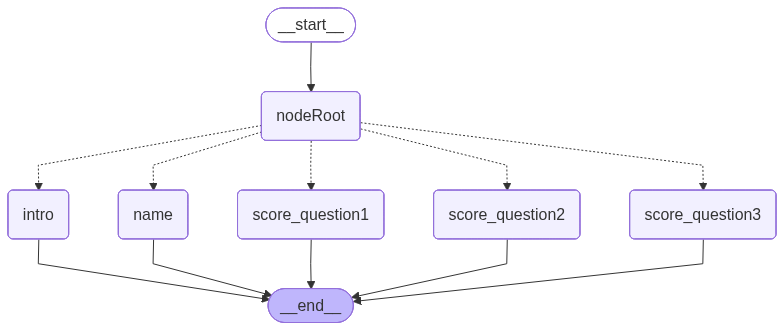

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_groq import ChatGroq
def state_from_job(job):
  state={"name":""
      ,"intro":""
      ,"question1":""
      ,"question2":""
      ,"question3":""
      ,"score_question1":""
      ,"impro_question1":""
      ,"impro_question2":""
      ,"impro_question3":""
      ,"score_question2":""
      ,"score_question3":""
      ,"reponce": ""
      ,"summary":""
      ,"messages": []
      ,"answer": ""}
  job=job

  base_instruction = (f"you are AI that help user prepa for job interveiw give the user technical question related to his domain:{job}"
                      "return only one question and don't add any comment")
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke(base_instruction )
  print(response.content)
  state["question1"]=response.content
  base_instruction = (f"you are AI that help user prepa for job interveiw give the user technical question related to his domain:{job}"
                      "return only one question and don't add any comment"
                      f"make sure that the question is deffernet form this question {state["question1"]} ")
  llm = ChatGroq(model="llama-3.1-8b-instant")
  response = llm.invoke(base_instruction )
  print(response.content)
  state["question2"]=response.content
  return state

In [ ]:
!git clone https://github.com/nari-labs/dia.git

In [ ]:
from dia.dia.model import Dia

def dia(text,audi_file):
  model = Dia.from_pretrained("nari-labs/Dia-1.6B-0626", compute_dtype="float16")

  text = ""

  output = model.generate(
      text,
      use_torch_compile=False,
      verbose=True,
      cfg_scale=3.0,
      temperature=1.8,
      top_p=0.90,
      cfg_filter_top_k=50,
  )

  model.save_audio(audi_file, output)



In [ ]:
!pip install faster-whisper

In [ ]:
from faster_whisper import WhisperModel

def whisper(audio_file, output_file):
    model_size = "large-v3"

    # Load model only once → MUCH faster
    model = WhisperModel(model_size, device="cpu", compute_type="int8")

    # Transcribe audio
    segments, info = model.transcribe(audio_file, beam_size=5)

    print(f"Detected language '{info.language}' ({info.language_probability:.2f})")

    # Save output text
    with open(output_file, "w", encoding="utf-8") as f:
        for segment in segments:
            line = f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}"
            print(line)
            f.write(segment.text + "\n")  # only text, no timestamps

In [ ]:
import sounddevice as sd
import numpy as np
import wavio
import time
import os

SILENCE_THRESHOLD = 0.01     # adjust if needed
SILENCE_TIMEOUT = 10         # seconds
FS = 44100                   # sample rate

def record_until_silence(output_file):
    print("🎙️ Listening... (stop talking for 20 seconds to trigger AI response)")

    audio_buffer = []
    last_voice_time = time.time()

    while True:
        # record 0.5 second chunk
        chunk = sd.rec(int(0.5 * FS), samplerate=FS, channels=1, dtype='float32')
        sd.wait()

        audio_buffer.append(chunk)

        # check if chunk is silence
        volume = np.abs(chunk).mean()

        if volume > SILENCE_THRESHOLD:
            last_voice_time = time.time()   # user is still speaking

        # check timeout
        if time.time() - last_voice_time > SILENCE_TIMEOUT:
            print("⏳ Silence detected for 20 seconds")
            break

    # save audio
    audio = np.concatenate(audio_buffer, axis=0)
    wavio.write(output_file, audio, FS, sampwidth=2)
    print("✔️ Saved:", output_file)

#add the job name of the user that u did get from the website
job="data science"
state=state_from_job(job)

def live_voice_loop():

    while True:
        # 1️⃣ RECORD UNTIL SILENCE
        record_until_silence("user_input.wav")

        # 2️⃣ SPEECH → TEXT
        whisper("user_input.wav", "input.txt")

        with open("input.txt", "r") as f:
            user_text = f.read().strip()

        print("\n🗣️ User:", user_text)

        if user_text.lower() in ["exit", "quit", "stop"]:
            print("🔚 Ending session...")
            break

        # 3️⃣ LLM
        state=app.invoke(state)
        response =state["answer"].content
        print("🤖 LLM:", response)

        with open("response.txt", "w") as f:
            f.write(response)

        # 4️⃣ TEXT → SPEECH
        dia("response.txt", "response.wav")

        # 5️⃣ PLAY
        print("🔊 Speaking...")
        os.system("aplay response.wav")

In [ ]:
state={"name":""
    ,"intro":""
    ,"score_question1":""
    ,"impro_question1":""
    ,"impro_question2":""
    ,"impro_question3":""
    ,"score_question2":""
    ,"score_question3":""
    ,"reponce": ""
    ,"summary":""
    ,"messages": []
    ,"answer": ""}
while True:
  res=input("you :  ")
  state["reponce"]=res
  state=app.invoke(state)
  print(state["answer"].content)
  print(state)

you :  hey
node name :
No information about your full name was provided. Would you like to share it?
Hello! I'm your AI interviewer. I'm glad we're starting a new conversation today. Could you please tell me your full name?
Hello! I'm your AI interviewer. I'm glad we're starting a new conversation today. Could you please tell me your full name?
{'name': '', 'intro': '', 'question1': '', 'score_question1': '', 'impro_question1': '', 'question2': '', 'score_question2': '', 'impro_question2': '', 'question3': '', 'score_question3': '', 'impro_question3': '', 'reponce': 'hey', 'summary': '', 'messages': ['User: hey', "AI: Hello! I'm your AI interviewer. I'm glad we're starting a new conversation today. Could you please tell me your full name?"], 'answer': AIMessage(content="Hello! I'm your AI interviewer. I'm glad we're starting a new conversation today. Could you please tell me your full name?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_toke

KeyboardInterrupt: Interrupted by user

In [ ]:
#my name is ahmid ben ahmid
#i did studied in enig as ai engernig and i want to be really good ai engenering taht's why i wan to creat amwzing ai
# A compiled language is fully translated into machine code before execution, resulting in a standalone executable that typically runs faster and more efficiently, while an interpreted language is executed line by line at runtime by an interpreter, making it more flexible and easier to test but generally slower because the translation happens as the program runs.
#TCP is a connection-oriented protocol that ensures reliable data transfer by establishing a connection, checking for errors, and resending lost packets, making it suitable for applications where accuracy matters like web browsing or file transfer. UDP is connectionless and sends data without guaranteeing delivery, order, or error correction, which makes it much faster and ideal for real-time applications like gaming, voice calls, or live streaming where speed is more important than perfect accuracy.
# To solve this problem, I would first restate the goal: I need to reverse the digits of a 32-bit signed integer and make sure the result stays within the valid range. I also need to avoid using 64-bit integers, so I must detect overflow manually.


In [ ]:
from test import reverse

testdict={
123:321,
-123:-321,
120:21,
8463847412:0,
100:1,
5463847412:2147483645,
1020102000:2010201,
-1010010001:-1000100101,
-8463847412:0,
-6463847412:-2147483646,
2147483657:0,
-2147483646:0}

def dictcheck():
    counter = 0
    score =0
    for i in testdict :
        if  reverse(i) == testdict[i]:
            if counter<=3 :
                score+=5
            else : score+=10
        counter+=1

    return score

In [ ]:
#API

from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

app = FastAPI()



# ----------------------------
# API Models
# ----------------------------
class State(BaseModel):
    data: dict


# ----------------------------
# API Endpoint
# ----------------------------
@app.post("/intervew")
def intervew( State):
  if state["job"]!="":
    state=state_from_job(job)
    return state


  if (state["name"]==""
  or state["intro"]==""
  or state["score_question1"]==""
  or state["score_question2"]==""
    ):
        whisper(state["respoce"], "input.txt")

        with open("input.txt", "r") as f:
            user_text = f.read().strip()

        print("\n🗣️ User:", user_text)

        if user_text.lower() in ["exit", "quit", "stop"]:
            print("🔚 Ending session...")
            break

        # 3️⃣ LLM
        state=app.invoke(state)
        response =state["answer"].content
        print("🤖 LLM:", response)

        with open("response.txt", "w") as f:
            f.write(response)

        # 4️⃣ TEXT → SPEECH
        dia("response.txt", "response.wav")

        # 5️⃣ PLAY
        print("🔊 Speaking...")
        os.system("aplay response.wav")
        return state

  else:
    state["score_question3"]=dictcheck()
    state["totale"]=int(state["score_question1"])+int(state["score_question2"])+int(state["score_question3"])
    return state




# ----------------------------
# Run server
# ----------------------------
if __name__ == "__main__":
    uvicorn.run("api:app", host="0.0.0.0", port=8000, reload=True)